# Text generation with a transformer model

This notebook demonstrates how to build a text generation model using a transformer from scratch. The Kalevala code base (https://github.com/mikkopere/Neuroverkkoprojekti/blob/main/LLM_Keras_Kalevala.ipynb) was used as a reference as per the assignment instructions. The goal is to investigate the model from two perspectives: Speed vs. Quality and Maximum Quality. 

The work started with using Alice in Wonderland as the training data, as it is a text with a well known style. The model was trained with different hyperparameters but the end results were basically gibberish. The thought then was that the style of the text is perhaps close to gibberish and maybe a bit short for this kind of model. Next, the model was trained with Moby Dick as it is a much longer book. Results weren´t still that much improving and then AI found possible issue with cross-split sequence leakage which was fixed. After this the loss curves and perplexity values got more reasonable, but the generated text was still not always coherent. This was still chosen as the way forward. The Moby Dick book was downloaded from the Gutenberg Project and cleaned up from Project Gutenberg related texts. 

The model was then looped with different configs regarding:

    - vocabulary size (1000, 2000, 4000)
    - sequence length (32, 64, 128 tokens)
    - embedding dimension (64, 128, 256, 384)
    - number of transformer layers (1, 2, 3, 4)
    - feed-forward dimension (128, 256, 512, 768)
    - temperature during text generation (0.5, 0.8, 1.0, 1.2)

The Kalevala code base was changed to be able to run in these loops and also to save results in dataframe with information of used hyperparameter. Perplexity was added as a metric as it provides interesting information about how the model chooses the next words. When the looping was working and initial results were checked, the notebook was modified to be able to run on Google Colab.

In [ ]:
# Mount Google Drive 
from google.colab import drive
drive.mount('/content/drive')

# Install sentencepiece
!pip install sentencepiece

# Set working directory
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/mobydickproject')

Mounted at /content/drive


In [2]:
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/mobydickproject'))

['text_generator.ipynb', 'mobydick.txt']


In [1]:
# Cell 1: Setup and imports
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'  # You can change to 'jax' or 'torch' if preferred

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
import sentencepiece as spm
import time
# Needs: conda install -c conda-forge sentencepiece

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")

Keras version: 3.13.2
Keras backend: tensorflow


In [4]:
# Cell 2: Load and prepare text data
# Load the Moby Dick text
#with open('/content/drive/MyDrive/Colab Notebooks/mobydickproject/mobydick.txt', 'r', encoding='utf-8-sig') as file:
#    text = file.read()
with open('mobydick.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")

Text length: 1191786 characters
First 100 characters: CHAPTER 1. Loomings.

Call me Ishmael. Some years ago—never mind how long precisely—having
little or


In [ ]:

def train_tokenizer(train_text, vocab_size):
    with open("train_split.txt", "w", encoding="utf-8") as f:
        f.write(train_text)
    spm.SentencePieceTrainer.train(
        input="train_split.txt",
        model_prefix=f"moby_vocab{vocab_size}",
        vocab_size=vocab_size,
        model_type="bpe",
        character_coverage=1.0,
        pad_id=3,
        pad_piece="<pad>",
        train_extremely_large_corpus=True
    )
    sp = spm.SentencePieceProcessor()
    sp.load(f"moby_vocab{vocab_size}.model")
    return sp

In [6]:
SPLIT_RATIO = 0.8
RANDOM_SEED = 42

split_char = int(len(text) * SPLIT_RATIO)
train_text = text[:split_char]
val_text   = text[split_char:]

def make_sequences(tokens, seq_len, stride):
    sequences = []
    for i in range(0, len(tokens) - seq_len, stride):
        sequences.append(tokens[i:i+seq_len+1])
    sequences = np.array(sequences)
    return sequences[:, :-1], sequences[:, 1:]

def prepare_data(sp, seq_len, stride=32):
    train_pieces = sp.encode_as_ids(train_text)
    val_pieces   = sp.encode_as_ids(val_text)
    train_inputs, train_targets = make_sequences(train_pieces, seq_len, stride)
    val_inputs,   val_targets   = make_sequences(val_pieces,   seq_len, stride)
    print(f"  Train sequences: {train_inputs.shape}  Val: {val_inputs.shape}")
    return train_inputs, train_targets, val_inputs, val_targets

In [7]:
# Cell 5: Build the Transformer model using different configurations

def get_positional_encoding(max_len, d_model):
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000**angles)
    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])
    return pos_encoding

def create_causal_mask(size):
    return 1 - np.triu(np.ones((size, size)), k=1)

configs = [
    {"embed_dim": 64,  "num_heads": 2, "ff_dim": 128, "num_layers": 1},
    {"embed_dim": 128, "num_heads": 2, "ff_dim": 256, "num_layers": 2},
    {"embed_dim": 256, "num_heads": 4, "ff_dim": 512, "num_layers": 3},
    {"embed_dim": 384, "num_heads": 6, "ff_dim": 768, "num_layers": 4},
]

def build_model(embed_dim, num_heads, ff_dim, num_layers, seq_len):
    inputs = keras.Input(shape=(seq_len,))
    x = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)
    x = x + get_positional_encoding(seq_len, embed_dim)
    causal_mask = create_causal_mask(seq_len)
    for _ in range(num_layers):
        attn = keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim // num_heads
        )(x, x, attention_mask=causal_mask)
        attn = keras.layers.Dropout(0.1)(attn)
        x = keras.layers.LayerNormalization()(x + attn)
        ffn = keras.Sequential([
            keras.layers.Dense(ff_dim, activation="relu"),
            keras.layers.Dense(embed_dim),
            keras.layers.Dropout(0.1)
        ])
        x = keras.layers.LayerNormalization()(x + ffn(x))
    outputs = keras.layers.Dense(sp.get_piece_size())(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(3e-4),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )
    return model

In [8]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0, seq_len=64):
    """Generate text based on a prompt with proper lowercase handling."""
    # Convert prompt to lowercase to match training data
    lowercase_prompt = prompt#.lower()

    # Encode the prompt
    input_ids = sp.encode_as_ids(lowercase_prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_len:
        padding_length = seq_len - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_len:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text

In [11]:
vocab_sizes  = [1000, 2000, 4000]
seq_lengths  = [32, 64, 128]
temperatures = [0.5, 0.8, 1.0, 1.2]
eval_prompts = [
    "Call me Ishmael",
    "The whale",
    "Captain Ahab",
]

results = []
for vocab_size in vocab_sizes:
    print(f"\n{'='*60}")
    print(f"VOCAB SIZE: {vocab_size}")
    print(f"{'='*60}")

    sp = train_tokenizer(train_text, vocab_size)

    for seq_len in seq_lengths:
        print(f"\n  --- seq_length: {seq_len} ---")

        train_inputs, train_targets, val_inputs, val_targets = prepare_data(sp, seq_len)

        for i, cfg in enumerate(configs):
            print(f"\n  Config {i+1}: {cfg}")

            start = time.time()
            model = build_model(seq_len=seq_len, **cfg)

            history = model.fit(
                train_inputs, train_targets,
                validation_data=(val_inputs, val_targets),
                batch_size=64,
                epochs=15,
                callbacks=[
                    keras.callbacks.EarlyStopping(
                        monitor="val_loss", patience=3, restore_best_weights=True
                    )
                ],
                verbose=1
            )
            duration = time.time() - start

            best_val_loss  = min(history.history["val_loss"])
            val_perplexity = float(np.exp(best_val_loss))

            # Plot curves
            train_perplexity = [np.exp(l) for l in history.history['loss']]
            val_perplexity_curve = [np.exp(l) for l in history.history['val_loss']]

            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            fig.suptitle(f"vocab={vocab_size} seq={seq_len} embed={cfg['embed_dim']} layers={cfg['num_layers']}")

            axes[0].plot(history.history['loss'], label='Train')
            axes[0].plot(history.history['val_loss'], label='Val')
            axes[0].set_title('Loss')
            axes[0].set_xlabel('Epoch')
            axes[0].set_ylabel('Loss')
            axes[0].legend()
            axes[0].grid()

            axes[1].plot(history.history.get('accuracy', []), label='Train')
            axes[1].plot(history.history.get('val_accuracy', []), label='Val')
            axes[1].set_title('Accuracy')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('Accuracy')
            axes[1].legend()
            axes[1].grid()

            axes[2].plot(train_perplexity, label='Train')
            axes[2].plot(val_perplexity_curve, label='Val')
            axes[2].set_title('Perplexity')
            axes[2].set_xlabel('Epoch')
            axes[2].set_ylabel('Perplexity')
            axes[2].legend()
            axes[2].grid()

            plt.tight_layout()
            plt.show()

            # Temperature sweep
            for temp in temperatures:
                for prompt in eval_prompts:
                    generated = generate_text(model, sp, prompt, num_tokens=80, temperature=temp, seq_len=seq_len)
                    print(f"  temp={temp} | {prompt}: {generated[:150]}")

            results.append({
                "vocab_size":    vocab_size,
                "seq_length":    seq_len,
                "embed_dim":     cfg["embed_dim"],
                "num_layers":    cfg["num_layers"],
                "ff_dim":        cfg["ff_dim"],
                "best_val_loss": round(best_val_loss, 4),
                "perplexity":    round(val_perplexity, 1),
                "time_sec":      round(duration, 1)
            })
            df = pd.DataFrame(results)
            df.to_csv('results_checkpoint.csv', index=False)

print("\n===== FULL RESULTS =====")
print(df.to_string(index=False))

Output hidden; open in https://colab.research.google.com to view.

Output is not shown as the notebook was run on Colab, but results were saved in a csv file. The run included loss, accuracy and perplexity curves for all the different configs. They all looked almost the same, with only some of them showing signs of overfitting at later epochs. All were plateauing towards the end so more epochs would probably not have improved the results any more. The text generations were not saved, but they were mostly not coherent. In later cells there are some examples of generated texts with different configs based on the following plot.

The plot below shows Time vs. Quality (perplexity used here) for all the different configs. The lower the perplexity, the better the quality. Models that took longer time to train, would seem to have better quality but not necessary in a way that it would be worth the extra time. More analysis of the results is done below the plot.

===== FULL RESULTS =====
 vocab_size  seq_length  embed_dim  num_layers  ff_dim  best_val_loss  perplexity  time_sec
       1000          32         64           1     128         4.4872        88.9      29.9
       1000          32        128           2     256         4.3073        74.2      41.5
       1000          32        256           3     512         4.1695        64.7      75.2
       1000          32        384           4     768         4.1098        60.9     146.7
       1000          64         64           1     128         4.4221        83.3      32.8
       1000          64        128           2     256         4.2478        70.0      53.3
       1000          64        256           3     512         4.0581        57.9     111.2
       1000          64        384           4     768         4.0501        57.4     230.8
       1000         128         64           1     128         4.4238        83.4      36.7
       1000         128        128           2     256 

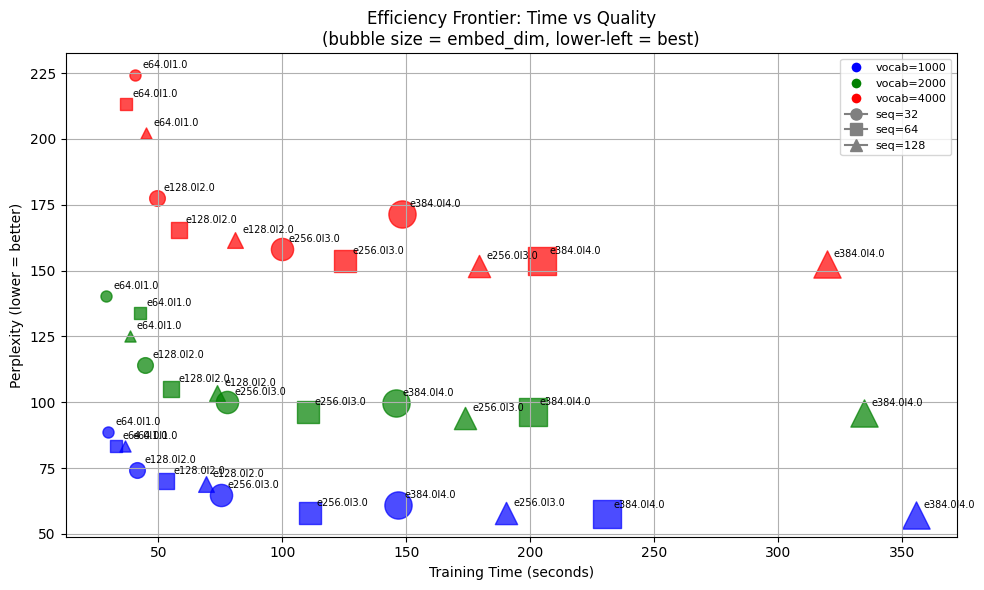

In [ ]:
# Cell 7: Final results summary and frontier plot

# Summary table
print("===== FULL RESULTS =====")
print(df.to_string(index=False))

# Scatter: time vs perplexity (lower-left = better)
plt.figure(figsize=(10, 6))

colors = {1000: 'blue', 2000: 'green', 4000: 'red'}
markers = {32: 'o', 64: 's', 128: '^'}

for _, row in df.iterrows():
    plt.scatter(
        row['time_sec'],
        row['perplexity'],
        color=colors[row['vocab_size']],
        marker=markers[row['seq_length']],
        s=row['embed_dim'],  # bubble size = model size
        alpha=0.7
    )
    plt.annotate(
        f"e{row['embed_dim']}l{row['num_layers']}",
        (row['time_sec'], row['perplexity']),
        fontsize=7,
        textcoords="offset points",
        xytext=(5, 5)
    )

# Manual legends
from matplotlib.lines import Line2D
color_legend = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=8, label=f'vocab={v}')
                for v, c in colors.items()]
marker_legend = [Line2D([0],[0], marker=m, color='gray', markersize=8, label=f'seq={s}')
                 for s, m in markers.items()]

plt.legend(handles=color_legend + marker_legend, fontsize=8)
plt.xlabel('Training Time (seconds)')
plt.ylabel('Perplexity (lower = better)')
plt.title('Efficiency Frontier: Time vs Quality\n(bubble size = embed_dim, lower-left = best)')
plt.grid(True)
plt.tight_layout()
plt.show()

During the running of this experiment in previous code cells, the generated texts were shown in the run outputs. This is not shown in this notebook as this is loaded from drive. As there were many different configs, it was also a bit difficult to evaluate the generated texts. They all seemed to be a bit incoherent and some had more gibberish than others. The most had been able to generate words related to the theme of the book (sea, ship, whale, captain etc.) but most sentences were not coherent.

Based on the plot above, the best model in regards of perplexity vs. time would seem to be the one with 1000 vocab size, 128 sequence length, 256 embedding dimension and 1 transformer layer. Perplexity was chosen here as the main metric as it makes it possible to evaluate how well the model is able to predict the next word. All of the "blue" models (vocab size 1000) have perplexity under 100, which means that the model chooses from 100 most probable words when predicting. This as such does not sound that good, but considering the size of the vocabulary (1000) it is actually pretty good. The "orange" models (vocab size 4000) have perplexity around 200, which is significantly worse than the "blue" models. However, it feels a bit odd that the lower vocab size would lead to better results, but it is possible that the model with larger vocab size would need more hyperparameter tuning to get better results. 

One of the "orange" models are chosen to compare the generated text with the best quality vs. time "blue" model. The chosen "orange" model has 32 sequence length, 64 embedding dimension and 1 transformer layers. This is the model with the worst perplexity to evaluate the generated texts with the efficient "blue" model. The third model is the one with the best perplexity (vocab size 1000, sequence length 128, embedding dimension 384 and 4 transformer layers) to evaluate if a larger model (and longer training time) would lead to better results.

These text tests were run locally after loading the results_checkpoint.csv from Google Drive. It would perhaps be better to save the models during previous loop, but this was not done and also saving 36 models seems over the top. This will work just as fine as a way to compare these two models. 

In [ ]:
eval_prompts = [
    "Call me Ishmael",
    "The whale",
    "Captain Ahab",
]

# Choose which configs to generate from — pick interesting ones
selected = [
    {"vocab_size": 1000, "seq_length": 128, "embed_dim": 64,  "num_layers": 1},  # fastest
    {"vocab_size": 1000, "seq_length": 128, "embed_dim": 256, "num_layers": 3},  # balanced
    {"vocab_size": 1000, "seq_length": 128, "embed_dim": 384, "num_layers": 4},  # best quality
]

for cfg in selected:
    # Find matching row in results
    row = df[
        (df['vocab_size'] == cfg['vocab_size']) &
        (df['seq_length'] == cfg['seq_length']) &
        (df['embed_dim']  == cfg['embed_dim']) &
        (df['num_layers'] == cfg['num_layers'])
    ].iloc[0]

    print(f"\n{'='*60}")
    print(f"vocab={cfg['vocab_size']} seq={cfg['seq_length']} embed={cfg['embed_dim']} layers={cfg['num_layers']}")
    print(f"Perplexity: {row['perplexity']}  |  Training time: {row['time_sec']}s")
    print(f"{'='*60}")

    # Retrain this config
    sp = train_tokenizer(train_text, cfg['vocab_size'])
    train_inputs, train_targets, val_inputs, val_targets = prepare_data(sp, cfg['seq_length'])
    model = build_model(seq_len=cfg['seq_length'], 
                        embed_dim=cfg['embed_dim'],
                        num_heads={64:2, 128:2, 256:4, 384:6}[cfg['embed_dim']],
                        ff_dim={64:128, 128:256, 256:512, 384:768}[cfg['embed_dim']],
                        num_layers=cfg['num_layers'])
    model.fit(train_inputs, train_targets,
              validation_data=(val_inputs, val_targets),
              batch_size=64, epochs=15,
              callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
              verbose=0)

    for temp in [0.8, 1.0, 1.2]:
        print(f"\nTemperature {temp}:")
        for prompt in eval_prompts:
            generated = generate_text(model, sp, prompt, num_tokens=100, 
                                      temperature=temp, seq_len=cfg['seq_length'])
            print(f"  {prompt}: {generated[:200]}")


vocab=1000 seq=128 embed=64 layers=1
Perplexity: 83.4  |  Training time: 36.7s
  Train sequences: (10498, 128)  Val: (2664, 128)

Temperature 0.8:
  Call me Ishmael: Call me Ishmael, for the devilier. But not the whales, and masured; and that of a cheston of modder to the vast widefulness, to the true, and with the bests, as a very longer. In the ighed to beextoat
  The whale: The whale, and leaved—Mast Jonah. But the death the cleple into the Hartering from Ahab. In extical veser Herope. Amer the white bodies, and foot be recely, and not climing home. Toved to be in their 
  Captain Ahab: Captain Ahab tries, and ut possibly confine of the trows. Tashured? “Me, so much as if it. “Doberence. “I meward to ves again to my sun; a ske is, and an addered stop the most suregents. In a very spr

Temperature 1.0:
  Call me Ishmael: Call me Ishmael, CHAPTER Bildad might have inser; “_)—fin—onhe’s surmore:—Scrizle upon what is whatever ruding that name of the shar-sued, Captain had this com; and

All models were tested with the same three prompts: "Call me Ishmael", "The whale" and "Captain Ahab". These were chosen as they are well known sentences/words from the book and it is interesting to see how the model continues these sentences. The temperatures tested were 0.8, 1.0 and 1.2. Temperature of 1.0 would mean that the model chooses the next word based on the probabilities it has learned during training, but a lower temperature would make distribution sharper and thus almost always choosing the most probable word. A higher temperature would make probability distribution flatter and choosing more randomly from the possible words.

All models had some jibberish and the sentences were not that coherent. The "blue" models might be said to have better sentence structures, but only slightly better than the "orange" model. With this level of nonsense in the sentences, it is hard to ascertain which temperatures would be better. After asking Claude AI to evaluate the generated texts, it stated that the temperature of 0.8 is the best readable across all configs deeming them clearly better and the 1.2 the worst. It also states that the balanced "blue" model "reads like broken 19th century prose" and the "orange" model produces more made up words such as "devilier", "cheston" and "modder". I would classify all models as reading like very broken 19th century prose written by someone whose first language is not English.

The remaining question is, how a better model would be achieved. It feels counterintuitive that the smaller vocabulary size would lead to better results, but as stated previously, it is possible that the larger vocabulary models would need even more hyperparameter tuning. When asking Claude AI to either offer suggestions for improving the models or offer suggestions why this set up is not achieving that good results in terms of coherence, it stated that tokenization might be an issue and that the data (Moby Dick) is not repeating patterns frequently enough for the models to learn robust generalisations. So the issue might still be the size of the data rather than size of the model and the hyperparameters available for optimization. 